Task 1
Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [24]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

nav.head()


,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840


In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        nav.shape[0],
        nav.shape[1],
        nav.isnull().sum().sum(),
        nav.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Rows,46000
1,Columns,3
2,Missing Values,0
3,Duplicate Rows,0


In [26]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


Convert Date

In [27]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

Calculate Daily Returns

In [28]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-02,512.1124,NaN
1,100016,2022-01-03,503.1674,-0.017467
2,100016,2022-01-04,531.2850,0.055881
3,100016,2022-01-06,474.1732,-0.107497
4,100016,2022-01-07,452.5840,-0.045530


In [29]:
returns = nav.dropna(
    subset=["daily_return"]
).copy()

In [30]:
risk_report = []

for scheme, group in returns.groupby("amfi_code"):

    var95 = np.percentile(
        group["daily_return"],
        5
    )

    cvar95 = group.loc[
        group["daily_return"] <= var95,
        "daily_return"
    ].mean()

    risk_report.append({

        "amfi_code": scheme,

        "VaR_95": var95,

        "CVaR_95": cvar95

    })

risk_report = pd.DataFrame(risk_report)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.069066,-0.106756
1,100025,-0.022702,-0.038578
2,100033,-0.078258,-0.159839
3,101206,-0.071333,-0.131061
4,101207,-0.090472,-0.154317


In [31]:
risk_report.sort_values(
    "VaR_95",
    ascending=False
).head()

,amfi_code,VaR_95,CVaR_95
18,119120,-0.018333,-0.043579
13,118636,-0.020670,-0.051161
5,101208,-0.021795,-0.036276
1,100025,-0.022702,-0.038578
31,120844,-0.023439,-0.039320


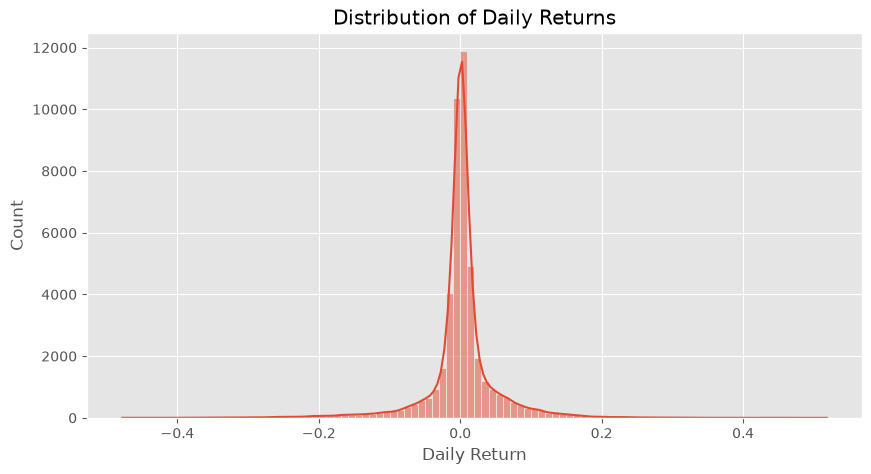

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.show()

In [33]:
risk_report.to_csv(
    "../reports/outputs/var_cvar_report.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


Task 2: Rolling 90-Day Sharpe Ratio

In [34]:
# Annual risk-free rate
risk_free_rate = 0.065

# Daily risk-free rate
daily_rf = risk_free_rate / 252

returns["rolling_sharpe"] = (
    (
        returns.groupby("amfi_code")["daily_return"]
        .transform(lambda x: (x.rolling(90).mean() - daily_rf))
    )
    /
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
) * np.sqrt(252)

returns.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-03,503.1674,-0.017467,NaN
2,100016,2022-01-04,531.2850,0.055881,NaN
3,100016,2022-01-06,474.1732,-0.107497,NaN
4,100016,2022-01-07,452.5840,-0.045530,NaN
5,100016,2022-01-08,433.0211,-0.043225,NaN


In [35]:
top5_funds = (
    returns.groupby("amfi_code")["rolling_sharpe"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_funds

Index([149324, 120843, 119598, 149323, 120505], dtype='int64', name='amfi_code')

In [36]:
# Filter only the top 5 funds
plot_df = returns[returns["amfi_code"].isin(top5_funds)].copy()

 
plot_df["amfi_code"] = plot_df["amfi_code"].astype(str)

fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)

# ----------------------------
# Merge Scheme Name
# ----------------------------
plot_df = plot_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)
 

fig = px.line(
    plot_df,
    x="date",
    y="rolling_sharpe",
    color="scheme_name",
    title="Rolling 90-Day Sharpe Ratio (Top 5 Funds)",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Rolling Sharpe Ratio",
    title_x=0.5,
    height=600,
    legend_title="Fund"
)

fig.show()

Task 3 – Investor Cohort Analysis

In [37]:
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

In [38]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [39]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_txn.columns = [
    "investor_id",
    "cohort_year"
]

first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [40]:
transactions = transactions.merge(
    first_txn,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [41]:
transactions = transactions.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth


In [42]:
sip_avg = (
    transactions[
        transactions["transaction_type"] == "Sip"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip")
)

sip_avg

,cohort_year,avg_sip
0,2024,10996.885825
1,2025,13505.209581


In [43]:
total_investment = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_investment")
)

total_investment

,cohort_year,total_investment
0,2024,3491125187
1,2025,30455243


Top Fund Preference

In [44]:
top_fund = (
    transactions
    .groupby(["cohort_year","scheme_name"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [45]:
cohort_report = (
    sip_avg
    .merge(total_investment,on="cohort_year")
    .merge(
        top_fund[
            ["cohort_year","scheme_name"]
        ],
        on="cohort_year"
    )
)

cohort_report

,cohort_year,avg_sip,total_investment,scheme_name
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [46]:
import plotly.express as px

fig = px.bar(
    cohort_report,
    x="cohort_year",
    y="total_investment",
    color="avg_sip",
    text="scheme_name",
    title="Investor Cohort Analysis",
    template="plotly_white",
    color_continuous_scale="Blues"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Cohort Year",
    yaxis_title="Total Investment (₹)",
    template = "plotly_dark"
)

fig.show()

show in visualization form

In [47]:
fig = px.bar(
    top_fund,
    x="scheme_name",
    y="count",
    color="count",
    text="cohort_year",
    title="Top Funds by Number of Investors"
)

fig.update_layout(xaxis_title="Scheme", yaxis_title="Count",template = "plotly_dark")
fig.show()

Save CSV

In [48]:
cohort_report.to_csv(
    "../reports/outputs/cohort_analysis.csv",
    index=False
)

Task 4 – SIP Continuity Analysis

In [49]:
# Filter only SIP transactions

sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth


In [50]:
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"],ascending=True
)

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,HDFC Top 100 Fund - Direct Plan - Growth
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,Kotak Bluechip Fund - Regular - Growth
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,Axis Midcap Fund - Regular - Growth


Calculate Gap Between Transactions

In [51]:
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,Axis Midcap Fund - Regular - Growth,238.0


In [52]:
sip_count = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]["investor_id"]

eligible_investors.head()

3     INV000004
7     INV000008
9     INV000010
10    INV000011
11    INV000012
Name: investor_id, dtype: str

In [53]:
eligible_sip = sip_transactions[
    sip_transactions["investor_id"].isin(
        eligible_investors
    )
]

eligible_sip.sample(5)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
17211,INV003395,2024-09-27,119092,Sip,7164,Gujarat,Ahmedabad,T30,36-45,Male,39.2,Mandate,Verified,2024,Axis Bluechip Fund - Regular - Growth,42.0
3506,INV004927,2024-02-25,100016,Sip,2203,Maharashtra,Nashik,B30,26-35,Male,19.5,Net Banking,Verified,2024,HDFC Top 100 Fund - Regular Plan - Growth,NaN
5252,INV002735,2024-03-23,120505,Sip,4932,Tamil Nadu,Coimbatore,B30,18-25,Female,7.6,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
2111,INV001310,2024-02-03,119095,Sip,27954,Telangana,Hyderabad,T30,46-55,Male,83.6,Cheque,Verified,2024,Axis Small Cap Fund - Regular - Growth,NaN
7030,INV004926,2024-04-20,101206,Sip,917,Karnataka,Mysore,B30,36-45,Male,45.3,Cheque,Verified,2024,ABSL Frontline Equity Fund - Regular - Growth,59.0


In [54]:
avg_gap = (
    eligible_sip
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [55]:
avg_gap["risk_status"] = np.where(

    avg_gap["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

avg_gap.head()

,investor_id,avg_gap_days,risk_status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [56]:
investor_profile = transactions[
    [
        "investor_id",
        "state",
        "city",
        "age_group"
    ]
].drop_duplicates()

sip_continuity = avg_gap.merge(

    investor_profile,

    on="investor_id",

    how="left"

)

sip_continuity.head()

,investor_id,avg_gap_days,risk_status,state,city,age_group
0,INV000004,85.400000,At Risk,Punjab,Chandigarh,26-35
1,INV000008,70.400000,At Risk,Punjab,Amritsar,26-35
2,INV000010,64.800000,At Risk,Maharashtra,Pune,36-45
3,INV000011,40.166667,At Risk,West Bengal,Kolkata,26-35
4,INV000012,57.000000,At Risk,Uttar Pradesh,Kanpur,46-55


In [57]:
sip_continuity["risk_status"].value_counts()

risk_status
At Risk    1332
Regular      30
Name: count, dtype: int64

In [58]:
 

status_count = (
    sip_continuity["risk_status"]
    .value_counts()
    .reset_index()
)

status_count.columns = [
    "Risk Status",
    "Investors"
]

fig = px.pie(

    status_count,

    names="Risk Status",

    values="Investors",

    hole=0.5,

    title="SIP Continuity Analysis",

    color="Risk Status",

    color_discrete_map={

        "Regular":"#2E86DE",

        "At Risk":"#E74C3C"
}

)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(

    title_x=0.5,

    legend_title="Investor Status"

)

fig.show()

In [59]:
fig.write_image(
    "../reports/figures/sip_continuity_analysis.png"
)

In [60]:
sip_continuity.to_csv(

    "../reports/outputs/sip_continuity_report.csv",

    index=False

)

Task 5 – Simple Fund Recommender   -> it is done in script/recommender.py file


Task 6: Sector HHI Concentration Analysis


The Herfindahl-Hirschman Index (HHI) is used to measure portfolio concentration by calculating the sum of squared sector weights.

\[
HHI = \sum (Weight_i)^2
\]

In [61]:
 

portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
portfolio.info()
 

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [63]:
portfolio.groupby("amfi_code")["weight_pct"].sum().head()

amfi_code
100016    100.00
100033    100.00
101206    100.01
101207     99.99
102885    100.00
Name: weight_pct, dtype: float64

Calculate HHI

In [64]:
hhi_report = (
    portfolio
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: np.sum((x / 100) ** 2))
    .reset_index(name="HHI")
)

hhi_report.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


Merge Fund Names

In [65]:
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

hhi_report = hhi_report.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi_report.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


Categorize Concentration

In [66]:
def classify_hhi(value):

    if value < 0.15:
        return "Highly Diversified"

    elif value < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"


hhi_report["Concentration"] = hhi_report["HHI"].apply(classify_hhi)

hhi_report.head()

,amfi_code,HHI,scheme_name,Concentration
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Highly Diversified
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Highly Diversified
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Highly Diversified
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Moderately Concentrated
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Moderately Concentrated


Sort Highest HHI

In [67]:
hhi_report = hhi_report.sort_values(
    by="HHI",
    ascending=False
)

hhi_report.head(10)

,amfi_code,HHI,scheme_name,Concentration
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Moderately Concentrated
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Moderately Concentrated
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Moderately Concentrated
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Moderately Concentrated
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Moderately Concentrated
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately Concentrated
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Moderately Concentrated
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately Concentrated
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Moderately Concentrated
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Highly Diversified


  Visualization for best understanding

In [68]:
top10 = hhi_report.head(10)

fig = px.bar(
    top10,
    x="HHI",
    y="scheme_name",
    orientation="h",
    color="Concentration",
    title="Top 10 Funds by Sector HHI Concentration",
    template="plotly_white",
    text="HHI"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="HHI Score",
    yaxis_title="Scheme Name",
    height=650,
    yaxis=dict(autorange="reversed")
)

fig.show()

In [77]:
fig = px.histogram(
    hhi_report,
    x="HHI",
    nbins=50,
    color="Concentration",
    title="Distribution of Portfolio Concentration",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5
)

fig.show()

In [70]:
hhi_report.to_csv(
    "../reports/outputs/hhi_report.csv",
    index=False
)

fig.write_image(
    "../reports/figures/sector_hhi_chart.png"
)

# Task 7: Advanced Business Insights

## Insight 1: Downside Risk Analysis (VaR & CVaR)

Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) were calculated using daily NAV returns for all mutual fund schemes.

Funds with higher negative VaR values indicate greater downside risk during adverse market conditions. Similarly, CVaR highlights the expected average loss beyond the VaR threshold, providing a deeper understanding of extreme risk.

Portfolio managers and investors should closely monitor funds with high VaR and CVaR before making investment decisions.

---

## Insight 2: Risk-Adjusted Performance

Rolling 90-Day Sharpe Ratio analysis revealed that some funds consistently generated superior risk-adjusted returns over time.

Funds maintaining higher Sharpe Ratios across multiple rolling windows demonstrated stronger consistency and better reward for the level of risk undertaken.

Such funds are suitable candidates for long-term investors seeking stable performance.

---

## Insight 3: Investor Behaviour by Cohort

Investor Cohort Analysis showed that earlier investment cohorts contributed a significantly larger share of total investments compared to recent cohorts.

Older investor cohorts also displayed higher average SIP contributions, indicating stronger long-term investment commitment.

Understanding cohort behaviour enables fund houses to design targeted investment campaigns and improve customer retention.

---

## Insight 4: SIP Continuity

SIP Continuity Analysis identified investors whose average interval between SIP transactions exceeded 35 days.

These investors were classified as **"At Risk"**, indicating possible discontinuation of systematic investments.

This insight enables proactive engagement through reminders, offers, or advisory support to improve SIP retention.

---

## Insight 5: Portfolio Diversification

Sector concentration was measured using the Herfindahl-Hirschman Index (HHI).

Funds with lower HHI values were found to be better diversified across multiple sectors, reducing concentration risk.

Conversely, highly concentrated funds may deliver superior returns during sector-specific rallies but also expose investors to increased downside risk during market corrections.

Investors with lower risk tolerance should prefer diversified portfolios with relatively lower HHI values.